In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
os.chdir('/content/drive/MyDrive/MMIC')

print(f"Current working directory changed to: {os.getcwd()}")

Current working directory changed to: /content/drive/MyDrive/MMIC


In [3]:
import os
import pandas as pd
import numpy as np

DATA_DIR = ""

def find_file(possible_names, data_dir=DATA_DIR):
    for name in possible_names:
        path = os.path.join(data_dir, name)
        if os.path.exists(path):
            return path
    return None

patients_file = find_file(["patients.csv"])
diagnoses_file = find_file(["diagnoses_icd.csv"])
d_icd_file = find_file(["d_icd_diagnoses.csv"])
admissions_file = find_file(["admissions.csv"])
omr_file = find_file(["omr.csv"])
prescriptions_file = find_file(["prescriptions.csv"])

print("patients_file:", patients_file)
print("diagnoses_file:", diagnoses_file)
print("d_icd_file:", d_icd_file)
print("admissions_file:", admissions_file)
print("omr_file:", omr_file)
print("prescriptions_file:", prescriptions_file)

patients = pd.read_csv(patients_file)
diagnoses_icd = pd.read_csv(diagnoses_file)
d_icd_diagnoses = pd.read_csv(d_icd_file)
admissions = pd.read_csv(admissions_file)
omr = pd.read_csv(omr_file)
prescriptions = pd.read_csv(prescriptions_file)

print("\nPATIENTS")
print(patients.shape)
print(patients.columns.tolist())
print(patients.head())

print("\nDIAGNOSES_ICD")
print(diagnoses_icd.shape)
print(diagnoses_icd.columns.tolist())
print(diagnoses_icd.head())

print("\nD_ICD_DIAGNOSES")
print(d_icd_diagnoses.shape)
print(d_icd_diagnoses.columns.tolist())
print(d_icd_diagnoses.head())

print("\nADMISSIONS")
print(admissions.shape)
print(admissions.columns.tolist())
print(admissions.head())

print("\nOMR")
print(omr.shape)
print(omr.columns.tolist())
print(omr.head())

print("\nPRESCRIPTIONS")
print(prescriptions.shape)
print(prescriptions.columns.tolist())
print(prescriptions.head())

patients_file: patients.csv
diagnoses_file: diagnoses_icd.csv
d_icd_file: d_icd_diagnoses.csv
admissions_file: admissions.csv
omr_file: omr.csv
prescriptions_file: prescriptions.csv


/tmp/ipykernel_31620/1120316865.py:33: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  prescriptions = pd.read_csv(prescriptions_file)



PATIENTS
(299712, 6)
['subject_id', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']
   subject_id gender  anchor_age  anchor_year anchor_year_group         dod
0    10000032      F          52         2180       2014 - 2016  2180-09-09
1    10000048      F          23         2126       2008 - 2010         NaN
2    10000068      F          19         2160       2008 - 2010         NaN
3    10000084      M          72         2160       2017 - 2019  2161-02-13
4    10000102      F          27         2136       2008 - 2010         NaN

DIAGNOSES_ICD
(4756326, 5)
['subject_id', 'hadm_id', 'seq_num', 'icd_code', 'icd_version']
   subject_id   hadm_id  seq_num icd_code  icd_version
0    10000032  22595853        1     5723            9
1    10000032  22595853        2    78959            9
2    10000032  22595853        3     5715            9
3    10000032  22595853        4    07070            9
4    10000032  22595853        5      496            9

D_ICD_DIAGNOSES
(

In [7]:
import pandas as pd
import numpy as np


d_icd_diagnoses["long_title_lower"] = d_icd_diagnoses["long_title"].astype(str).str.lower()

htn_dict = d_icd_diagnoses[
    d_icd_diagnoses["long_title_lower"].str.contains("hypertension|hypertensive", na=False)
].copy()

print("All hypertension-related diagnosis descriptions:")
print(htn_dict[["icd_code", "icd_version", "long_title"]].drop_duplicates().sort_values(["icd_version", "icd_code"]).head(100))


exclude_terms = [
    "secondary",
    "pregnancy",
    "preeclampsia",
    "eclampsia",
    "portal",
    "pulmonary",
    "intracranial",
    "ocular"
]

pattern_exclude = "|".join(exclude_terms)

htn_primary_dict = htn_dict[
    ~htn_dict["long_title_lower"].str.contains(pattern_exclude, na=False)
].copy()

print("\nAfter broad exclusion of non-primary/system-specific hypertension terms:")
print(htn_primary_dict[["icd_code", "icd_version", "long_title"]].drop_duplicates().sort_values(["icd_version", "icd_code"]).head(100))


htn_codes = htn_primary_dict[["icd_code", "icd_version"]].drop_duplicates()

htn_dx = diagnoses_icd.merge(
    htn_codes,
    on=["icd_code", "icd_version"],
    how="inner"
).copy()

print("\nHypertension diagnosis rows:", htn_dx.shape)
print("Unique hypertension subjects:", htn_dx["subject_id"].nunique())

if "anchor_age" in patients.columns:
    adult_patients = patients[patients["anchor_age"] >= 18].copy()
else:
    raise ValueError("anchor_age not found in patients table. Send patient columns.")

htn_adults = adult_patients.merge(
    htn_dx[["subject_id"]].drop_duplicates(),
    on="subject_id",
    how="inner"
).copy()

print("\nAdult hypertension patients:", htn_adults["subject_id"].nunique())
print(htn_adults.head())

All hypertension-related diagnosis descriptions:
      icd_code  icd_version                                 long_title
3524      3482            9           Benign intracranial hypertension
3654     36042            9                     Blind hypertensive eye
3704     36211            9                   Hypertensive retinopathy
3850     36504            9                        Ocular hypertension
4649      4010            9           Malignant essential hypertension
...        ...          ...                                        ...
22203   H35033           10        Hypertensive retinopathy, bilateral
22204   H35039           10  Hypertensive retinopathy, unspecified eye
22439    H4005           10                        Ocular hypertension
22440   H40051           10             Ocular hypertension, right eye
22441   H40052           10              Ocular hypertension, left eye

[100 rows x 3 columns]

After broad exclusion of non-primary/system-specific hypertension terms:
 

In [8]:
# -----------------------------
# 1. Convert dates
# -----------------------------
admissions["admittime"] = pd.to_datetime(admissions["admittime"], errors="coerce")
admissions["dischtime"] = pd.to_datetime(admissions["dischtime"], errors="coerce")


htn_adm = admissions.merge(
    htn_adults[["subject_id"]],
    on="subject_id",
    how="inner"
).copy()

# Drop rows with missing admission time
htn_adm = htn_adm.dropna(subset=["admittime"]).copy()

# Sort by patient and time
htn_adm = htn_adm.sort_values(["subject_id", "admittime"]).copy()

# -----------------------------
# 3. Gap calculation
# -----------------------------
htn_adm["prev_admittime"] = htn_adm.groupby("subject_id")["admittime"].shift(1)
htn_adm["gap_days"] = (htn_adm["admittime"] - htn_adm["prev_admittime"]).dt.days

# -----------------------------
# 4. Patient summary
# -----------------------------
patient_timeline = htn_adm.groupby("subject_id").agg(
    n_admissions=("hadm_id", "nunique"),
    first_admission=("admittime", "min"),
    last_admission=("admittime", "max"),
    max_gap_days=("gap_days", "max")
).reset_index()

patient_timeline["max_gap_days"] = patient_timeline["max_gap_days"].fillna(0)
patient_timeline["care_gap_gt_180"] = (patient_timeline["max_gap_days"] > 180).astype(int)
patient_timeline["followup_days"] = (
    patient_timeline["last_admission"] - patient_timeline["first_admission"]
).dt.days

print(patient_timeline.head())
print(patient_timeline.describe(include="all"))
print("\nPatients with >180 day gap:")
print(patient_timeline["care_gap_gt_180"].value_counts(dropna=False))

   subject_id  n_admissions     first_admission      last_admission  \
0    10000635             1 2136-06-19 14:24:00 2136-06-19 14:24:00   
1    10000764             1 2132-10-14 23:31:00 2132-10-14 23:31:00   
2    10000980             7 2188-01-03 17:41:00 2193-08-15 01:01:00   
3    10001176             1 2186-11-29 03:56:00 2186-11-29 03:56:00   
4    10001217             2 2157-11-18 22:56:00 2157-12-18 16:58:00   

   max_gap_days  care_gap_gt_180  followup_days  
0           0.0                0              0  
1           0.0                0              0  
2         760.0                1           2050  
3           0.0                0              0  
4          29.0                0             29  
         subject_id  n_admissions                first_admission  \
count  8.947500e+04  89475.000000                          89475   
mean   1.501276e+07      3.030992  2152-10-31 22:58:43.865883648   
min    1.000064e+07      1.000000            2105-10-04 17:26:00   
2

In [9]:
htn_longitudinal = patient_timeline[
    patient_timeline["n_admissions"] >= 2
].copy()

print("Patients with >=2 admissions:", htn_longitudinal.shape[0])

htn_adm_long = htn_adm.merge(
    htn_longitudinal[["subject_id", "first_admission"]],
    on="subject_id",
    how="inner"
).copy()

print(htn_adm_long.head())

Patients with >=2 admissions: 48942
   subject_id   hadm_id           admittime           dischtime deathtime  \
0    10000980  29654838 2188-01-03 17:41:00 2188-01-05 17:30:00       NaN   
1    10000980  26913865 2189-06-27 07:38:00 2189-07-03 03:00:00       NaN   
2    10000980  24947999 2190-11-06 20:57:00 2190-11-08 15:58:00       NaN   
3    10000980  25242409 2191-04-03 18:48:00 2191-04-11 16:21:00       NaN   
4    10000980  25911675 2191-05-23 15:33:00 2191-05-24 17:14:00       NaN   

  admission_type admit_provider_id admission_location  \
0       EW EMER.            P20N5X     EMERGENCY ROOM   
1       EW EMER.            P30KEH     EMERGENCY ROOM   
2       EW EMER.            P434W4     EMERGENCY ROOM   
3       EW EMER.            P33K8A     EMERGENCY ROOM   
4       EW EMER.            P29CGZ     EMERGENCY ROOM   

         discharge_location insurance language marital_status  \
0          HOME HEALTH CARE  Medicare  ENGLISH        MARRIED   
1          HOME HEALTH CARE 

In [10]:
# Days from first admission = index date
htn_adm_long["days_from_index"] = (
    htn_adm_long["admittime"] - htn_adm_long["first_admission"]
).dt.days

htn_adm_long["window_90d"] = (htn_adm_long["days_from_index"] // 90).astype(int)

visit_90d = htn_adm_long.groupby(["subject_id", "window_90d"]).agg(
    visit_count=("hadm_id", "nunique")
).reset_index()

print(visit_90d.head(20))

    subject_id  window_90d  visit_count
0     10000980           0            1
1     10000980           6            1
2     10000980          11            1
3     10000980          13            2
4     10000980          14            1
5     10000980          22            1
6     10001217           0            2
7     10001401           0            3
8     10001401           1            2
9     10001401           8            1
10    10001877           0            1
11    10001877           6            1
12    10001884           0            4
13    10001884           4            1
14    10001884           7            1
15    10001884           8            1
16    10001884          11            1
17    10001884          18            3
18    10001884          19            1
19    10001884          20            7


In [11]:
# -----------------------------
# 1. Check OMR columns likely containing date
# -----------------------------
print(omr.columns.tolist())

# Use chartdate
omr["chartdate"] = pd.to_datetime(omr["chartdate"], errors="coerce")

# -----------------------------
# 2. Keep BP-related rows
# -----------------------------
bp_omr = omr[
    omr["result_name"].astype(str).str.contains("Blood Pressure", case=False, na=False)
].copy()

print("BP OMR rows:", bp_omr.shape)
print(bp_omr[["subject_id", "chartdate", "result_name", "result_value"]].head(20))

# -----------------------------
# 3. Keep only hypertension longitudinal cohort
# -----------------------------
bp_omr = bp_omr.merge(
    htn_longitudinal[["subject_id", "first_admission"]],
    on="subject_id",
    how="inner"
).copy()

# Keep rows with valid dates
bp_omr = bp_omr.dropna(subset=["chartdate"]).copy()

# Days from index
bp_omr["days_from_index"] = (
    bp_omr["chartdate"] - bp_omr["first_admission"]
).dt.days

# Keep BP rows on/after index
bp_omr = bp_omr[bp_omr["days_from_index"] >= 0].copy()

# 90-day window
bp_omr["window_90d"] = (bp_omr["days_from_index"] // 90).astype(int)

# Count BP measurements per patient-window
bp_90d = bp_omr.groupby(["subject_id", "window_90d"]).agg(
    bp_count=("result_value", "count")
).reset_index()

print(bp_90d.head(20))

['subject_id', 'chartdate', 'seq_num', 'result_name', 'result_value']
BP OMR rows: (2179422, 5)
    subject_id  chartdate     result_name result_value
0     10000032 2180-04-27  Blood Pressure       110/65
21    10000032 2180-05-25  Blood Pressure       106/60
24    10000032 2180-06-01  Blood Pressure       121/77
27    10000032 2180-06-22  Blood Pressure       100/60
33    10000032 2180-06-30  Blood Pressure       102/60
36    10000032 2180-07-09  Blood Pressure        98/66
44    10000117 2174-10-14  Blood Pressure       124/66
46    10000117 2175-01-26  Blood Pressure       130/84
47    10000117 2175-01-27  Blood Pressure       100/66
49    10000117 2175-03-17  Blood Pressure       110/70
50    10000117 2175-04-28  Blood Pressure       110/70
51    10000117 2175-08-18  Blood Pressure       112/70
53    10000117 2175-09-08  Blood Pressure       110/70
57    10000117 2175-12-16  Blood Pressure       120/78
58    10000117 2176-02-01  Blood Pressure       110/60
59    10000117 2176-02-1

In [12]:
prescriptions["starttime"] = pd.to_datetime(prescriptions["starttime"], errors="coerce")
prescriptions["stoptime"] = pd.to_datetime(prescriptions["stoptime"], errors="coerce")

# Broad antihypertensive keyword list
antihyp_terms = [
    "amlodipine", "lisinopril", "losartan", "valsartan", "hydrochlorothiazide",
    "metoprolol", "atenolol", "carvedilol", "nifedipine", "chlorthalidone",
    "spironolactone", "clonidine", "enalapril", "enalaprilat", "olmesartan",
    "irbesartan", "bisoprolol", "triamterene", "sacubitril-valsartan"
]

pattern_rx = "|".join(antihyp_terms)

rx_htn = prescriptions[
    prescriptions["drug"].astype(str).str.lower().str.contains(pattern_rx, na=False)
].copy()

print("Antihypertensive prescription rows:", rx_htn.shape)
print(rx_htn[["subject_id", "hadm_id", "starttime", "drug"]].head(20))

# Join to longitudinal cohort
rx_htn = rx_htn.merge(
    htn_longitudinal[["subject_id", "first_admission"]],
    on="subject_id",
    how="inner"
).copy()

# Keep rows with valid start time
rx_htn = rx_htn.dropna(subset=["starttime"]).copy()

# Days from index
rx_htn["days_from_index"] = (
    rx_htn["starttime"] - rx_htn["first_admission"]
).dt.days

# Keep rows on/after index
rx_htn = rx_htn[rx_htn["days_from_index"] >= 0].copy()

# 90-day window
rx_htn["window_90d"] = (rx_htn["days_from_index"] // 90).astype(int)

# Count med activity per patient-window
rx_90d = rx_htn.groupby(["subject_id", "window_90d"]).agg(
    med_count=("drug", "count")
).reset_index()

print(rx_90d.head(20))

Antihypertensive prescription rows: (642618, 21)
     subject_id   hadm_id           starttime                           drug
9      10000032  22595853 2180-05-07 01:00:00                 Spironolactone
12     10000032  22595853 2180-05-08 08:00:00                 Spironolactone
152    10000635  26134563 2136-06-19 15:00:00     Triamterene-HCTZ (37.5/25)
181    10000764  27897940 2132-10-16 08:00:00            Metoprolol Tartrate
187    10000764  27897940 2132-10-15 20:00:00            Metoprolol Tartrate
191    10000764  27897940 2132-10-17 14:00:00            Metoprolol Tartrate
264    10000826  21086876 2146-12-19 10:00:00                 Spironolactone
494    10000980  20897796 2193-08-15 08:00:00                     Carvedilol
501    10000980  20897796 2193-08-15 08:00:00  NIFEdipine (Extended Release)
524    10000980  24947999 2190-11-07 12:00:00                     Lisinopril
528    10000980  24947999 2190-11-07 03:00:00                     Lisinopril
535    10000980  24947999 2

In [13]:
# Find max observed window across visits, BP, meds
max_visit = visit_90d.groupby("subject_id")["window_90d"].max().reset_index().rename(columns={"window_90d": "max_visit_w"})
max_bp = bp_90d.groupby("subject_id")["window_90d"].max().reset_index().rename(columns={"window_90d": "max_bp_w"})
max_rx = rx_90d.groupby("subject_id")["window_90d"].max().reset_index().rename(columns={"window_90d": "max_rx_w"})

max_windows = htn_longitudinal[["subject_id"]].merge(max_visit, on="subject_id", how="left")
max_windows = max_windows.merge(max_bp, on="subject_id", how="left")
max_windows = max_windows.merge(max_rx, on="subject_id", how="left")

max_windows = max_windows.fillna(0)

max_windows["max_window_90d"] = max_windows[["max_visit_w", "max_bp_w", "max_rx_w"]].max(axis=1).astype(int)

# Build full grid
rows = []
for _, row in max_windows.iterrows():
    sid = row["subject_id"]
    max_w = row["max_window_90d"]
    for w in range(int(max_w) + 1):
        rows.append((sid, w))

full_grid = pd.DataFrame(rows, columns=["subject_id", "window_90d"])

# Merge all features
aim1_90d = full_grid.merge(visit_90d, on=["subject_id", "window_90d"], how="left")
aim1_90d = aim1_90d.merge(bp_90d, on=["subject_id", "window_90d"], how="left")
aim1_90d = aim1_90d.merge(rx_90d, on=["subject_id", "window_90d"], how="left")

aim1_90d["visit_count"] = aim1_90d["visit_count"].fillna(0).astype(int)
aim1_90d["bp_count"] = aim1_90d["bp_count"].fillna(0).astype(int)
aim1_90d["med_count"] = aim1_90d["med_count"].fillna(0).astype(int)

print(aim1_90d.head(30))

    subject_id  window_90d  visit_count  bp_count  med_count
0   10000980.0           0            1         6         10
1   10000980.0           1            0         4          0
2   10000980.0           2            0         2          0
3   10000980.0           3            0         1          0
4   10000980.0           4            0         2          0
5   10000980.0           5            0         2          0
6   10000980.0           6            1         3          3
7   10000980.0           7            0         4          0
8   10000980.0           8            0         1          0
9   10000980.0           9            0         1          0
10  10000980.0          10            0         2          0
11  10000980.0          11            1         3          7
12  10000980.0          12            0         4          0
13  10000980.0          13            2         3         10
14  10000980.0          14            1         4          7
15  10000980.0          

In [14]:
aim1_90d = aim1_90d.sort_values(["subject_id", "window_90d"]).copy()

aim1_90d["zero_visit"] = (aim1_90d["visit_count"] == 0).astype(int)

aim1_90d["prev_zero_visit"] = (
    aim1_90d.groupby("subject_id")["zero_visit"].shift(1).fillna(0).astype(int)
)

# Approximation: 2 consecutive 90-day windows with no visit ≈ long gap
aim1_90d["approx_gap_gt_180"] = (
    (aim1_90d["zero_visit"] == 1) &
    (aim1_90d["prev_zero_visit"] == 1)
).astype(int)

print(aim1_90d.head(40))

    subject_id  window_90d  visit_count  bp_count  med_count  zero_visit  \
0   10000980.0           0            1         6         10           0   
1   10000980.0           1            0         4          0           1   
2   10000980.0           2            0         2          0           1   
3   10000980.0           3            0         1          0           1   
4   10000980.0           4            0         2          0           1   
5   10000980.0           5            0         2          0           1   
6   10000980.0           6            1         3          3           0   
7   10000980.0           7            0         4          0           1   
8   10000980.0           8            0         1          0           1   
9   10000980.0           9            0         1          0           1   
10  10000980.0          10            0         2          0           1   
11  10000980.0          11            1         3          7           0   
12  10000980

In [15]:
aim1_90d.to_csv("aim1_90d_features.csv", index=False)
patient_timeline.to_csv("aim1_patient_timeline.csv", index=False)

print("Saved:")
print(" - aim1_90d_features.csv")
print(" - aim1_patient_timeline.csv")

Saved:
 - aim1_90d_features.csv
 - aim1_patient_timeline.csv


In [16]:
# Clean diagnosis text
d_icd_diagnoses["long_title_lower"] = d_icd_diagnoses["long_title"].astype(str).str.lower()

# Start broad
htn_dict = d_icd_diagnoses[
    d_icd_diagnoses["long_title_lower"].str.contains("hypertension|hypertensive", na=False)
].copy()

# Exclude clearly unwanted categories
exclude_terms = [
    "pregnancy",
    "preeclampsia",
    "eclampsia",
    "gestation",
    "newborn",
    "maternal",
    "ocular",
    "eye",
    "retinopathy",
    "intracranial",
    "portal",
    "pulmonary",
    "orthostatic",
    "hypotension"
]

exclude_pattern = "|".join(exclude_terms)

htn_refined_dict = htn_dict[
    ~htn_dict["long_title_lower"].str.contains(exclude_pattern, na=False)
].copy()

print("Refined hypertension-related diagnoses:")
print(
    htn_refined_dict[["icd_code", "icd_version", "long_title"]]
    .drop_duplicates()
    .sort_values(["icd_version", "icd_code"])
    .head(150)
)

print("Total refined diagnosis dictionary rows:", htn_refined_dict.shape[0])

Refined hypertension-related diagnoses:
      icd_code  icd_version                                         long_title
4649      4010            9                   Malignant essential hypertension
4650      4011            9                      Benign essential hypertension
4651      4019            9                 Unspecified essential hypertension
4652     40200            9  Malignant hypertensive heart disease without h...
4653     40201            9  Malignant hypertensive heart disease with hear...
...        ...          ...                                                ...
90293  T465X5S           10  Adverse effect of other antihypertensive drugs...
90294   T465X6           10        Underdosing of other antihypertensive drugs
90295  T465X6A           10  Underdosing of other antihypertensive drugs, i...
90296  T465X6D           10  Underdosing of other antihypertensive drugs, s...
90297  T465X6S           10  Underdosing of other antihypertensive drugs, s...

[135 rows x

In [17]:
htn_refined_codes = htn_refined_dict[["icd_code", "icd_version"]].drop_duplicates()

htn_dx_refined = diagnoses_icd.merge(
    htn_refined_codes,
    on=["icd_code", "icd_version"],
    how="inner"
).copy()

print("Refined hypertension diagnosis rows:", htn_dx_refined.shape)
print("Unique refined hypertension subjects:", htn_dx_refined["subject_id"].nunique())

Refined hypertension diagnosis rows: (221375, 5)
Unique refined hypertension subjects: 89480


In [18]:
htn_adults_refined = adult_patients.merge(
    htn_dx_refined[["subject_id"]].drop_duplicates(),
    on="subject_id",
    how="inner"
).copy()

print("Refined adult hypertension patients:", htn_adults_refined["subject_id"].nunique())

Refined adult hypertension patients: 89480


In [19]:
htn_adm_refined = admissions.merge(
    htn_adults_refined[["subject_id"]],
    on="subject_id",
    how="inner"
).copy()

htn_adm_refined["admittime"] = pd.to_datetime(htn_adm_refined["admittime"], errors="coerce")
htn_adm_refined = htn_adm_refined.dropna(subset=["admittime"]).copy()
htn_adm_refined = htn_adm_refined.sort_values(["subject_id", "admittime"]).copy()

htn_adm_refined["prev_admittime"] = htn_adm_refined.groupby("subject_id")["admittime"].shift(1)
htn_adm_refined["gap_days"] = (htn_adm_refined["admittime"] - htn_adm_refined["prev_admittime"]).dt.days

patient_timeline_refined = htn_adm_refined.groupby("subject_id").agg(
    n_admissions=("hadm_id", "nunique"),
    first_admission=("admittime", "min"),
    last_admission=("admittime", "max"),
    max_gap_days=("gap_days", "max")
).reset_index()

patient_timeline_refined["max_gap_days"] = patient_timeline_refined["max_gap_days"].fillna(0)
patient_timeline_refined["care_gap_gt_180"] = (patient_timeline_refined["max_gap_days"] > 180).astype(int)
patient_timeline_refined["followup_days"] = (
    patient_timeline_refined["last_admission"] - patient_timeline_refined["first_admission"]
).dt.days

print(patient_timeline_refined.head())
print(patient_timeline_refined.describe(include="all"))

   subject_id  n_admissions     first_admission      last_admission  \
0    10000635             1 2136-06-19 14:24:00 2136-06-19 14:24:00   
1    10000764             1 2132-10-14 23:31:00 2132-10-14 23:31:00   
2    10000980             7 2188-01-03 17:41:00 2193-08-15 01:01:00   
3    10001176             1 2186-11-29 03:56:00 2186-11-29 03:56:00   
4    10001217             2 2157-11-18 22:56:00 2157-12-18 16:58:00   

   max_gap_days  care_gap_gt_180  followup_days  
0           0.0                0              0  
1           0.0                0              0  
2         760.0                1           2050  
3           0.0                0              0  
4          29.0                0             29  
         subject_id  n_admissions                first_admission  \
count  8.948000e+04  89480.000000                          89480   
mean   1.501270e+07      3.031046  2152-11-01 12:07:15.198479360   
min    1.000064e+07      1.000000            2105-10-04 17:26:00   
2

In [20]:
aim1_90d["subject_id"] = aim1_90d["subject_id"].astype("int64")
aim1_90d["window_90d"] = aim1_90d["window_90d"].astype("int64")
aim1_90d["visit_count"] = aim1_90d["visit_count"].astype("int64")
aim1_90d["bp_count"] = aim1_90d["bp_count"].astype("int64")
aim1_90d["med_count"] = aim1_90d["med_count"].astype("int64")

print(aim1_90d.dtypes)
print(aim1_90d.head())

subject_id           int64
window_90d           int64
visit_count          int64
bp_count             int64
med_count            int64
zero_visit           int64
prev_zero_visit      int64
approx_gap_gt_180    int64
dtype: object
   subject_id  window_90d  visit_count  bp_count  med_count  zero_visit  \
0    10000980           0            1         6         10           0   
1    10000980           1            0         4          0           1   
2    10000980           2            0         2          0           1   
3    10000980           3            0         1          0           1   
4    10000980           4            0         2          0           1   

   prev_zero_visit  approx_gap_gt_180  
0                0                  0  
1                0                  0  
2                1                  1  
3                1                  1  
4                1                  1  


In [21]:
# aim1_90d["engagement_score"] = (
#     aim1_90d["visit_count"] +
#     aim1_90d["bp_count"] +
#     aim1_90d["med_count"]
# )

In [22]:
# Start from broad hypertension dictionary again
d_icd_diagnoses["long_title_lower"] = d_icd_diagnoses["long_title"].astype(str).str.lower()

htn_dict = d_icd_diagnoses[
    d_icd_diagnoses["long_title_lower"].str.contains("hypertension|hypertensive", na=False)
].copy()

# Exclude non-target categories
exclude_terms = [
    "pregnancy",
    "preeclampsia",
    "eclampsia",
    "gestation",
    "maternal",
    "newborn",
    "ocular",
    "eye",
    "retinopathy",
    "intracranial",
    "portal",
    "pulmonary",
    "adverse effect",
    "poisoning",
    "overdose",
    "underdosing",
    "external cause",
    "drug-induced hypotension",
    "hypotension"
]

exclude_pattern = "|".join(exclude_terms)

htn_final_dict = htn_dict[
    ~htn_dict["long_title_lower"].str.contains(exclude_pattern, na=False)
].copy()

print(htn_final_dict[["icd_code", "icd_version", "long_title"]]
      .drop_duplicates()
      .sort_values(["icd_version", "icd_code"])
      .head(200))

print("Total final diagnosis dictionary rows:", htn_final_dict.shape[0])

      icd_code  icd_version                                         long_title
4649      4010            9                   Malignant essential hypertension
4650      4011            9                      Benign essential hypertension
4651      4019            9                 Unspecified essential hypertension
4652     40200            9  Malignant hypertensive heart disease without h...
4653     40201            9  Malignant hypertensive heart disease with hear...
...        ...          ...                                                ...
38250    O1043           10  Pre-existing secondary hypertension complicati...
38257    O1092           10  Unspecified pre-existing hypertension complica...
38258    O1093           10  Unspecified pre-existing hypertension complica...
41104     P292           10                              Neonatal hypertension
42396     R030           10  Elevated blood-pressure reading, without diagn...

[107 rows x 3 columns]
Total final diagnosis dictio

In [23]:
htn_final_codes = htn_final_dict[["icd_code", "icd_version"]].drop_duplicates()

htn_dx_final = diagnoses_icd.merge(
    htn_final_codes,
    on=["icd_code", "icd_version"],
    how="inner"
).copy()

htn_adults_final = adult_patients.merge(
    htn_dx_final[["subject_id"]].drop_duplicates(),
    on="subject_id",
    how="inner"
).copy()

print("Final adult hypertension patients:", htn_adults_final["subject_id"].nunique())

# admissions timeline
htn_adm_final = admissions.merge(
    htn_adults_final[["subject_id"]],
    on="subject_id",
    how="inner"
).copy()

htn_adm_final["admittime"] = pd.to_datetime(htn_adm_final["admittime"], errors="coerce")
htn_adm_final = htn_adm_final.dropna(subset=["admittime"]).copy()
htn_adm_final = htn_adm_final.sort_values(["subject_id", "admittime"]).copy()

htn_adm_final["prev_admittime"] = htn_adm_final.groupby("subject_id")["admittime"].shift(1)
htn_adm_final["gap_days"] = (htn_adm_final["admittime"] - htn_adm_final["prev_admittime"]).dt.days

patient_timeline_final = htn_adm_final.groupby("subject_id").agg(
    n_admissions=("hadm_id", "nunique"),
    first_admission=("admittime", "min"),
    last_admission=("admittime", "max"),
    max_gap_days=("gap_days", "max")
).reset_index()

patient_timeline_final["max_gap_days"] = patient_timeline_final["max_gap_days"].fillna(0)
patient_timeline_final["care_gap_gt_180"] = (patient_timeline_final["max_gap_days"] > 180).astype(int)
patient_timeline_final["followup_days"] = (
    patient_timeline_final["last_admission"] - patient_timeline_final["first_admission"]
).dt.days

print(patient_timeline_final.describe(include="all"))

Final adult hypertension patients: 89373
         subject_id  n_admissions                first_admission  \
count  8.937300e+04  89373.000000                          89373   
mean   1.501279e+07      3.029349  2152-11-01 04:50:29.918431232   
min    1.000064e+07      1.000000            2105-10-04 17:26:00   
25%    1.250381e+07      1.000000            2132-11-13 22:55:00   
50%    1.503136e+07      2.000000            2152-10-02 00:00:00   
75%    1.750747e+07      3.000000            2172-10-20 01:41:00   
max    1.999984e+07    238.000000            2210-09-05 14:34:00   
std    2.883469e+06      4.417436                            NaN   

                      last_admission  max_gap_days  care_gap_gt_180  \
count                          89373  89373.000000     89373.000000   
mean   2154-07-20 20:40:45.733945344    421.442650         0.379925   
min              2110-01-11 10:14:00      0.000000         0.000000   
25%              2134-07-17 16:49:00      0.000000         0.0

In [24]:
aim1_90d["engagement_score"] = (
    aim1_90d["visit_count"] +
    aim1_90d["bp_count"] +
    aim1_90d["med_count"]
)

print(aim1_90d.head())
print(aim1_90d["engagement_score"].describe())

   subject_id  window_90d  visit_count  bp_count  med_count  zero_visit  \
0    10000980           0            1         6         10           0   
1    10000980           1            0         4          0           1   
2    10000980           2            0         2          0           1   
3    10000980           3            0         1          0           1   
4    10000980           4            0         2          0           1   

   prev_zero_visit  approx_gap_gt_180  engagement_score  
0                0                  0                17  
1                0                  0                 4  
2                1                  1                 2  
3                1                  1                 1  
4                1                  1                 2  
count    742405.000000
mean          2.182976
std           3.749667
min           0.000000
25%           0.000000
50%           1.000000
75%           3.000000
max          95.000000
Name: engagement_

In [25]:
patient_features = aim1_90d.groupby("subject_id").agg(
    n_windows=("window_90d", "nunique"),
    total_visits=("visit_count", "sum"),
    total_bp=("bp_count", "sum"),
    total_meds=("med_count", "sum"),
    mean_visits=("visit_count", "mean"),
    mean_bp=("bp_count", "mean"),
    mean_meds=("med_count", "mean"),
    windows_with_no_visit=("zero_visit", "sum"),
    windows_with_gap_signal=("approx_gap_gt_180", "sum"),
    mean_engagement=("engagement_score", "mean"),
    max_engagement=("engagement_score", "max")
).reset_index()

patient_features["pct_zero_visit_windows"] = (
    patient_features["windows_with_no_visit"] / patient_features["n_windows"]
)

patient_features["pct_gap_signal_windows"] = (
    patient_features["windows_with_gap_signal"] / patient_features["n_windows"]
)

print(patient_features.head())
print(patient_features.describe())

   subject_id  n_windows  total_visits  total_bp  total_meds  mean_visits  \
0    10000980         23             7        66          39     0.304348   
1    10001217          1             2         4           0     2.000000   
2    10001401         13             6        26           0     0.461538   
3    10001877          7             2         0           3     0.285714   
4    10001884         22            22        35          15     1.000000   

    mean_bp  mean_meds  windows_with_no_visit  windows_with_gap_signal  \
0  2.869565   1.695652                     17                       13   
1  4.000000   0.000000                      0                        0   
2  2.000000   0.000000                     10                        8   
3  0.000000   0.428571                      5                        4   
4  1.590909   0.681818                     13                        9   

   mean_engagement  max_engagement  pct_zero_visit_windows  \
0         4.869565            

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_cols = [
    "mean_visits",
    "mean_bp",
    "mean_meds",
    "pct_zero_visit_windows",
    "pct_gap_signal_windows",
    "mean_engagement"
]

X = patient_features[cluster_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
patient_features["cluster_4"] = kmeans.fit_predict(X_scaled)

print(patient_features["cluster_4"].value_counts().sort_index())

cluster_summary = patient_features.groupby("cluster_4")[cluster_cols].mean()
print(cluster_summary)

cluster_4
0    11801
1    32900
2     2178
3     2063
Name: count, dtype: int64
           mean_visits   mean_bp  mean_meds  pct_zero_visit_windows  \
cluster_4                                                             
0             1.576376  0.765299   2.590328                0.156000   
1             0.286221  1.037891   0.572245                0.784086   
2             1.055707  7.921970   1.633673                0.449705   
3             2.439255  0.943602  13.770035                0.027901   

           pct_gap_signal_windows  mean_engagement  
cluster_4                                           
0                        0.030709         4.932003  
1                        0.637110         1.896357  
2                        0.259115        10.611350  
3                        0.001411        17.152892  


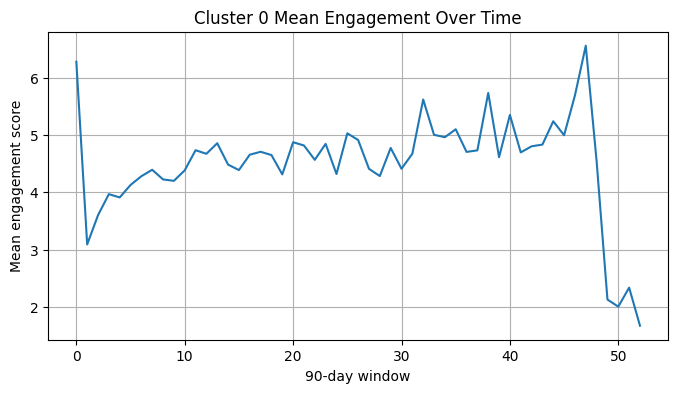

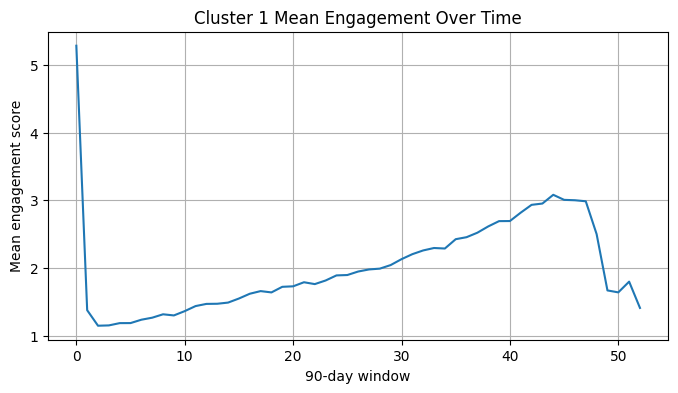

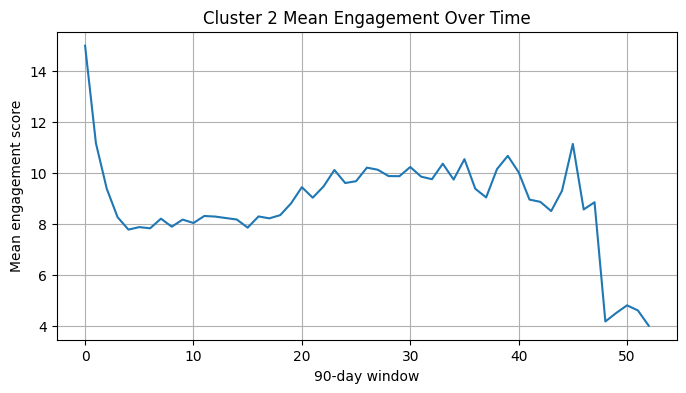

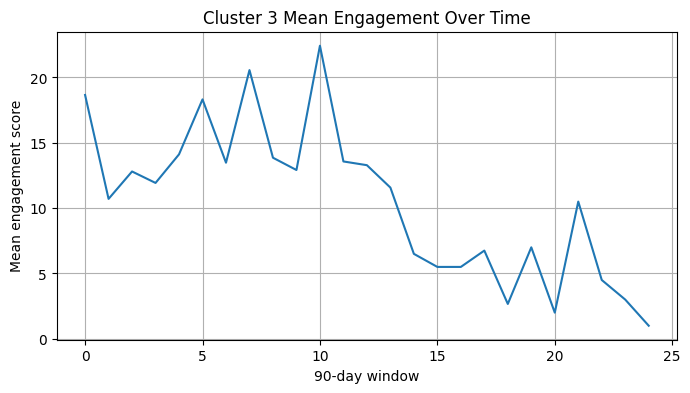

In [27]:
import matplotlib.pyplot as plt

# merge cluster labels back to 90-day table
aim1_plot = aim1_90d.merge(
    patient_features[["subject_id", "cluster_4"]],
    on="subject_id",
    how="left"
)

cluster_traj = aim1_plot.groupby(["cluster_4", "window_90d"]).agg(
    mean_visit_count=("visit_count", "mean"),
    mean_bp_count=("bp_count", "mean"),
    mean_med_count=("med_count", "mean"),
    mean_engagement=("engagement_score", "mean")
).reset_index()

for c in sorted(cluster_traj["cluster_4"].dropna().unique()):
    temp = cluster_traj[cluster_traj["cluster_4"] == c]
    plt.figure(figsize=(8, 4))
    plt.plot(temp["window_90d"], temp["mean_engagement"])
    plt.title(f"Cluster {c} Mean Engagement Over Time")
    plt.xlabel("90-day window")
    plt.ylabel("Mean engagement score")
    plt.grid(True)
    plt.show()

In [29]:
label_map = {
    0: "Sustained Engagers",
    1: "Early Dropouts",
    2: "BP-Monitored Intermittent",
    3: "High-Intensity Engagers"
}

patient_features["cluster_label"] = patient_features["cluster_4"].map(label_map)

In [30]:
patient_summary_labeled = patient_timeline_final.merge(
    patient_features[["subject_id", "cluster_4", "cluster_label"]],
    on="subject_id",
    how="inner"
)

print(patient_summary_labeled.head())

   subject_id  n_admissions     first_admission      last_admission  \
0    10000980             7 2188-01-03 17:41:00 2193-08-15 01:01:00   
1    10001217             2 2157-11-18 22:56:00 2157-12-18 16:58:00   
2    10001401             6 2131-06-04 00:00:00 2133-07-09 22:22:00   
3    10001877             2 2149-05-21 15:53:00 2150-11-21 23:02:00   
4    10001884            22 2125-10-18 16:50:00 2131-01-07 20:39:00   

   max_gap_days  care_gap_gt_180  followup_days  cluster_4       cluster_label  
0         760.0                1           2050          1      Early Dropouts  
1          29.0                0             29          0  Sustained Engagers  
2         603.0                1            766          1      Early Dropouts  
3         549.0                1            549          1      Early Dropouts  
4         632.0                1           1907          1      Early Dropouts  


In [31]:
phenotype_summary = patient_summary_labeled.groupby("cluster_label").agg(
    n_patients=("subject_id", "nunique"),
    mean_admissions=("n_admissions", "mean"),
    median_admissions=("n_admissions", "median"),
    mean_followup_days=("followup_days", "mean"),
    median_followup_days=("followup_days", "median"),
    pct_with_gap_gt_180=("care_gap_gt_180", "mean")
).reset_index()

phenotype_summary["pct_with_gap_gt_180"] *= 100

print(phenotype_summary)

               cluster_label  n_patients  mean_admissions  median_admissions  \
0  BP-Monitored Intermittent        2173         6.829268                5.0   
1             Early Dropouts       32843         4.655817                3.0   
2    High-Intensity Engagers        2061         3.395439                2.0   
3         Sustained Engagers       11769         4.706432                2.0   

   mean_followup_days  median_followup_days  pct_with_gap_gt_180  
0          642.613438                 351.0            54.210769  
1         1564.174162                1371.0            90.564199  
2           71.737991                  43.0             1.213003  
3          259.412524                 100.0            25.482199  


In [32]:
window_counts = aim1_plot.groupby(["cluster_4", "window_90d"]).agg(
    n_patients=("subject_id", "nunique")
).reset_index()

print(window_counts.head(20))
print(window_counts.sort_values(["cluster_4", "window_90d"]).tail(20))

    cluster_4  window_90d  n_patients
0           0           0       11801
1           0           1        7012
2           0           2        4569
3           0           3        3003
4           0           4        2194
5           0           5        1705
6           0           6        1378
7           0           7        1180
8           0           8        1027
9           0           9         876
10          0          10         764
11          0          11         664
12          0          12         607
13          0          13         544
14          0          14         502
15          0          15         471
16          0          16         423
17          0          17         380
18          0          18         358
19          0          19         324
     cluster_4  window_90d  n_patients
164          3           5          28
165          3           6          21
166          3           7          16
167          3           8          14
168    

In [34]:
aim1_90d_12 = aim1_90d[aim1_90d["window_90d"] <= 11].copy()

In [35]:
patient_features_12 = aim1_90d_12.groupby("subject_id").agg(
    n_windows=("window_90d", "nunique"),
    total_visits=("visit_count", "sum"),
    total_bp=("bp_count", "sum"),
    total_meds=("med_count", "sum"),
    mean_visits=("visit_count", "mean"),
    mean_bp=("bp_count", "mean"),
    mean_meds=("med_count", "mean"),
    windows_with_no_visit=("zero_visit", "sum"),
    windows_with_gap_signal=("approx_gap_gt_180", "sum"),
    mean_engagement=("engagement_score", "mean"),
    max_engagement=("engagement_score", "max")
).reset_index()

patient_features_12["pct_zero_visit_windows"] = (
    patient_features_12["windows_with_no_visit"] / patient_features_12["n_windows"]
)

patient_features_12["pct_gap_signal_windows"] = (
    patient_features_12["windows_with_gap_signal"] / patient_features_12["n_windows"]
)

In [36]:
patient_features_12_full = patient_features_12[patient_features_12["n_windows"] == 12].copy()
print(patient_features_12_full.shape)

(23883, 14)


In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_cols = [
    "mean_visits",
    "mean_bp",
    "mean_meds",
    "pct_zero_visit_windows",
    "pct_gap_signal_windows",
    "mean_engagement"
]

X = patient_features_12_full[cluster_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_12 = KMeans(n_clusters=4, random_state=42, n_init=10)
patient_features_12_full["cluster_4"] = kmeans_12.fit_predict(X_scaled)

cluster_summary_12 = patient_features_12_full.groupby("cluster_4")[cluster_cols].mean()
print(patient_features_12_full["cluster_4"].value_counts().sort_index())
print(cluster_summary_12)

cluster_4
0    15346
1     6240
2     1083
3     1214
Name: count, dtype: int64
           mean_visits   mean_bp  mean_meds  pct_zero_visit_windows  \
cluster_4                                                             
0             0.139130  0.602627   0.223402                0.882972   
1             0.401896  0.927885   0.750321                0.698504   
2             1.169283  1.363727   2.471453                0.395506   
3             0.414539  5.352485   0.684171                0.723778   

           pct_gap_signal_windows  mean_engagement  
cluster_4                                           
0                        0.776587         0.965159  
1                        0.492695         2.080101  
2                        0.184749         5.004463  
3                        0.543589         6.451194  


In [38]:
label_map_12 = {
    0: "Severe Early Dropouts",
    1: "Intermittent Engagers",
    2: "Sustained Engagers",
    3: "BP-Monitored Intermittent Engagers"
}

patient_features_12_full["cluster_label"] = patient_features_12_full["cluster_4"].map(label_map_12)

In [39]:
aim1_90d_12_labeled = aim1_90d_12.merge(
    patient_features_12_full[["subject_id", "cluster_4", "cluster_label"]],
    on="subject_id",
    how="inner"
)

In [40]:
phenotype_summary_12 = patient_features_12_full.groupby("cluster_label").agg(
    n_patients=("subject_id", "nunique"),
    mean_visits=("mean_visits", "mean"),
    mean_bp=("mean_bp", "mean"),
    mean_meds=("mean_meds", "mean"),
    mean_pct_zero=("pct_zero_visit_windows", "mean"),
    mean_pct_gap=("pct_gap_signal_windows", "mean"),
    mean_engagement=("mean_engagement", "mean")
).reset_index()

print(phenotype_summary_12)

                        cluster_label  n_patients  mean_visits   mean_bp  \
0  BP-Monitored Intermittent Engagers        1214     0.414539  5.352485   
1               Intermittent Engagers        6240     0.401896  0.927885   
2               Severe Early Dropouts       15346     0.139130  0.602627   
3                  Sustained Engagers        1083     1.169283  1.363727   

   mean_meds  mean_pct_zero  mean_pct_gap  mean_engagement  
0   0.684171       0.723778      0.543589         6.451194  
1   0.750321       0.698504      0.492695         2.080101  
2   0.223402       0.882972      0.776587         0.965159  
3   2.471453       0.395506      0.184749         5.004463  


In [41]:
# label_map_12 = {
#     0: "Severe Early Dropouts",
#     1: "Intermittent Engagers",
#     2: "Sustained Engagers",
#     3: "BP-Monitored Intermittent Engagers"
# }

# patient_features_12_full["cluster_label"] = patient_features_12_full["cluster_4"].map(label_map_12)

# print(patient_features_12_full[["subject_id", "cluster_4", "cluster_label"]].head())
# print(patient_features_12_full["cluster_label"].value_counts())

In [42]:
label_map_12 = {
    0: "Severe Early Dropouts",
    1: "Intermittent Engagers",
    2: "Sustained Engagers",
    3: "BP-Monitored Intermittent Engagers"
}

patient_features_12_full["cluster_label"] = patient_features_12_full["cluster_4"].map(label_map_12)

print(patient_features_12_full[["subject_id", "cluster_4", "cluster_label"]].head())
print(patient_features_12_full["cluster_label"].value_counts())

   subject_id  cluster_4          cluster_label
0    10000980          1  Intermittent Engagers
2    10001401          1  Intermittent Engagers
4    10001884          1  Intermittent Engagers
5    10002013          1  Intermittent Engagers
6    10002131          0  Severe Early Dropouts
cluster_label
Severe Early Dropouts                 15346
Intermittent Engagers                  6240
BP-Monitored Intermittent Engagers     1214
Sustained Engagers                     1083
Name: count, dtype: int64


In [43]:
phenotype_summary_12 = patient_features_12_full.groupby("cluster_label").agg(
    n_patients=("subject_id", "nunique"),
    mean_visits=("mean_visits", "mean"),
    mean_bp=("mean_bp", "mean"),
    mean_meds=("mean_meds", "mean"),
    mean_pct_zero=("pct_zero_visit_windows", "mean"),
    mean_pct_gap=("pct_gap_signal_windows", "mean"),
    mean_engagement=("mean_engagement", "mean")
).reset_index()

# Optional: nicer formatting
phenotype_summary_12["mean_visits"] = phenotype_summary_12["mean_visits"].round(3)
phenotype_summary_12["mean_bp"] = phenotype_summary_12["mean_bp"].round(3)
phenotype_summary_12["mean_meds"] = phenotype_summary_12["mean_meds"].round(3)
phenotype_summary_12["mean_pct_zero"] = (phenotype_summary_12["mean_pct_zero"] * 100).round(1)
phenotype_summary_12["mean_pct_gap"] = (phenotype_summary_12["mean_pct_gap"] * 100).round(1)
phenotype_summary_12["mean_engagement"] = phenotype_summary_12["mean_engagement"].round(3)

print(phenotype_summary_12)

                        cluster_label  n_patients  mean_visits  mean_bp  \
0  BP-Monitored Intermittent Engagers        1214        0.415    5.352   
1               Intermittent Engagers        6240        0.402    0.928   
2               Severe Early Dropouts       15346        0.139    0.603   
3                  Sustained Engagers        1083        1.169    1.364   

   mean_meds  mean_pct_zero  mean_pct_gap  mean_engagement  
0      0.684           72.4          54.4            6.451  
1      0.750           69.9          49.3            2.080  
2      0.223           88.3          77.7            0.965  
3      2.471           39.6          18.5            5.004  


In [44]:
patient_summary_12 = patient_timeline_final.merge(
    patient_features_12_full[["subject_id", "cluster_label"]],
    on="subject_id",
    how="inner"
)

timeline_summary_12 = patient_summary_12.groupby("cluster_label").agg(
    n_patients=("subject_id", "nunique"),
    mean_admissions=("n_admissions", "mean"),
    median_admissions=("n_admissions", "median"),
    mean_followup_days=("followup_days", "mean"),
    median_followup_days=("followup_days", "median"),
    pct_with_gap_gt_180=("care_gap_gt_180", "mean")
).reset_index()

timeline_summary_12["mean_admissions"] = timeline_summary_12["mean_admissions"].round(2)
timeline_summary_12["mean_followup_days"] = timeline_summary_12["mean_followup_days"].round(1)
timeline_summary_12["pct_with_gap_gt_180"] = (timeline_summary_12["pct_with_gap_gt_180"] * 100).round(1)

print(timeline_summary_12)

                        cluster_label  n_patients  mean_admissions  \
0  BP-Monitored Intermittent Engagers        1213             8.08   
1               Intermittent Engagers        6233             8.51   
2               Severe Early Dropouts       15321             4.06   
3                  Sustained Engagers        1079            22.94   

   median_admissions  mean_followup_days  median_followup_days  \
0                6.0              1676.7                1450.0   
1                7.0              1996.1                1788.0   
2                3.0              2113.5                2010.0   
3               17.0              2108.6                1894.0   

   pct_with_gap_gt_180  
0                 97.4  
1                 99.5  
2                 98.0  
3                 96.6  


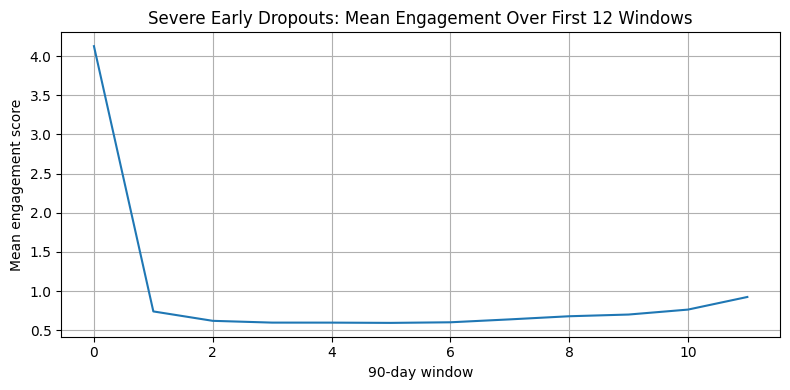

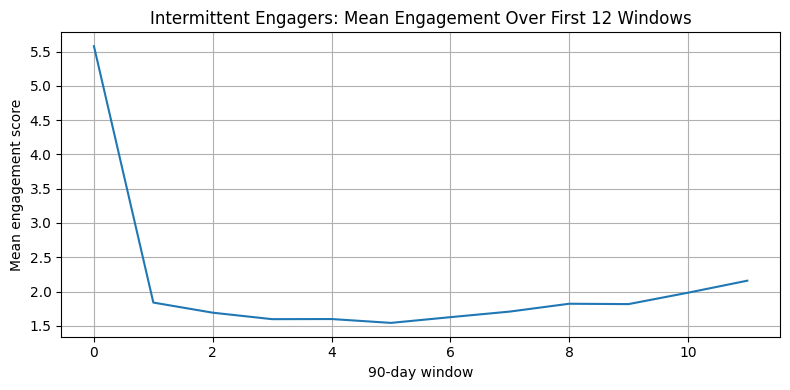

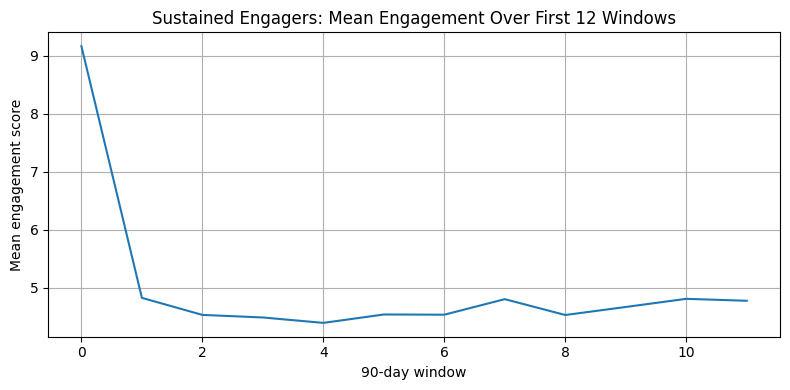

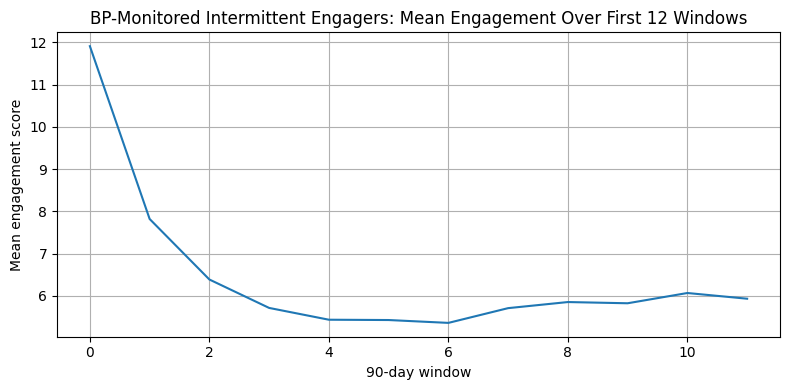

In [45]:
import matplotlib.pyplot as plt

curve_summary_12 = aim1_90d_12_labeled.groupby(["cluster_label", "window_90d"]).agg(
    mean_visit_count=("visit_count", "mean"),
    mean_bp_count=("bp_count", "mean"),
    mean_med_count=("med_count", "mean"),
    mean_engagement=("engagement_score", "mean"),
    n_patients=("subject_id", "nunique")
).reset_index()

labels_in_order = [
    "Severe Early Dropouts",
    "Intermittent Engagers",
    "Sustained Engagers",
    "BP-Monitored Intermittent Engagers"
]

for label in labels_in_order:
    temp = curve_summary_12[curve_summary_12["cluster_label"] == label]

    plt.figure(figsize=(8, 4))
    plt.plot(temp["window_90d"], temp["mean_engagement"])
    plt.title(f"{label}: Mean Engagement Over First 12 Windows")
    plt.xlabel("90-day window")
    plt.ylabel("Mean engagement score")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [47]:
phenotype_summary_12.to_csv("phenotype_summary_12.csv", index=False)
timeline_summary_12.to_csv("timeline_summary_12.csv", index=False)
curve_summary_12.to_csv("curve_summary_12.csv", index=False)

print("Saved:")
print(" - phenotype_summary_12.csv")
print(" - timeline_summary_12.csv")
print(" - curve_summary_12.csv")

Saved:
 - phenotype_summary_12.csv
 - timeline_summary_12.csv
 - curve_summary_12.csv


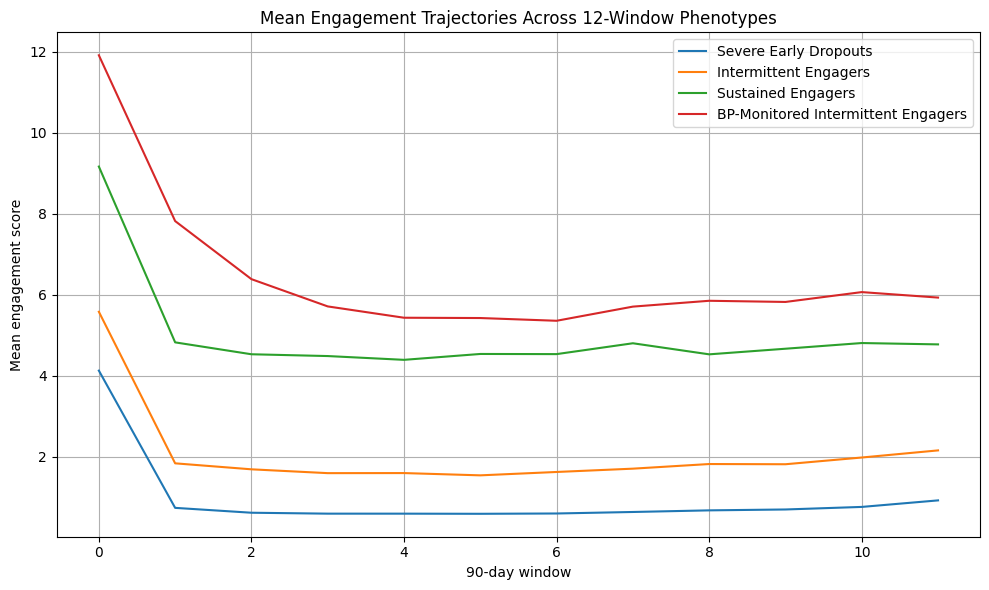

Saved: phenotype_trajectories_12windows.png


In [48]:
plt.figure(figsize=(10, 6))

for label in labels_in_order:
    temp = curve_summary_12[curve_summary_12["cluster_label"] == label]
    plt.plot(temp["window_90d"], temp["mean_engagement"], label=label)

plt.title("Mean Engagement Trajectories Across 12-Window Phenotypes")
plt.xlabel("90-day window")
plt.ylabel("Mean engagement score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("phenotype_trajectories_12windows.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: phenotype_trajectories_12windows.png")